# Le papier scanné du Sénat — census des écritures & validation Quiver

**But.** Chiffrer, pour le deck (galerie « Le papier Sénat : trois écritures » + slide 2e), la
**composition des 373 PTR papier** du Sénat (2014-2026) et prouver que **Quiver corrobore 0 %** de
cette voie. Tout est relu depuis des artefacts **figés** (census + sortie OCR + réconciliation) —
**aucun appel Vision** ici.

**Méthode (résumé).** Chaque scan est classé en **4 catégories** par Claude Vision
(`claude-sonnet-4-6`, cache versionné) selon la façon dont les transactions sont présentées :
`tapé` (formulaire standard, noms d'actifs tapés) · `manuscrit` (noms d'actifs à la main) ·
`annexe_courtier` (relevé de courtier « See Attachment », format libre) · `cas_a_part` (aucune
table de transactions). Puis **correction fondée sur la vérité-terrain OCR** : un doc est
`cas_a_part` **si et seulement si** il n'a produit **aucune transaction** dans la sortie OCR
(`06b_*`) — ce qui reclasse les docs `[lettre de garde + formulaire]` par leur formulaire.

## §1 — Le corpus papier Sénat (373 documents)

In [1]:
import pandas as pd, glob, re
pd.set_option("display.max_columns", 30)

paper = pd.read_csv("data/senate/tables/_paper_index_2014_2026.csv", dtype=str)
print("PTR papier Sénat 2014-2026 :", paper.shape, "| déposants :", paper["member"].nunique())
paper.head()

PTR papier Sénat 2014-2026 : (373, 4) | déposants : 14


,year,uuid,member,disclosure_date
0,2020,dbc1c728-6fe4-49d7-809b-d1c79f7b1376,RICHARD BLUMENTHAL,2020-12-22
1,2020,f45a6e12-e24c-4fac-8ced-3d704a179559,DIANNE FEINSTEIN,2020-12-15
2,2020,2a123633-1454-49ff-8c3b-c4028372a119,RICHARD BLUMENTHAL,2020-12-02
3,2020,7ce788ae-dbe0-46b2-ac9a-a1aa5a4ff62d,JOHN BOOZMAN,2020-11-10
4,2020,dfeac24c-e61d-4732-b200-ccae42657df2,JOHN BOOZMAN,2020-10-16


## §2 — Le census des écritures (1 ligne par document)

In [2]:
cen = pd.read_csv("data/senate/tables/_scan_census_senat.csv", dtype=str)
print("census :", cen.shape)
cen.head()

census : (373, 5)


,uuid,year,member,n_pages,category
0,5B7D23B8-661C-45AC-8B40-EAD128130E8D,2014,JACK REED,1,tape
1,06A375AE-B6BF-4CB9-A675-8E4703896A18,2014,JOHN HOEVEN,1,tape
2,9242F316-3F2F-48DE-AE71-F3D812EE33E5,2014,MARIA CANTWELL,1,tape
3,1FA31695-2481-47BC-A8B8-2B39D4D0B97E,2014,MARK R WARNER,2,tape
4,6BB34CE7-72BF-4F9A-B078-DDE209016DD6,2014,MARK R WARNER,2,tape


### §2.1 — Validation

Trois contrôles : (a) cas connus bien classés ; (b) somme = 373 ; (c) **recoupement OCR** — la
catégorie `cas_a_part` doit coïncider avec les docs **sans transaction** dans la sortie OCR.

In [3]:
# (a) cas connus
for m, exp in [("ROBERTS","manuscrit"), ("BOOZMAN","annexe_courtier"), ("BLUMENTHAL","tape")]:
    vc = cen[cen["member"].str.upper().str.contains(m)]["category"].value_counts()
    print(f"{m:12s} → {dict(vc)}  | dominante = {vc.index[0]}  (attendu {exp})")

# (b) somme
assert len(cen) == 373, "le census doit couvrir les 373"
print("\nsomme catégories =", len(cen), "OK")

# (c) recoupement avec la sortie OCR : quels docs ont ≥1 transaction
UURE = re.compile(r'[0-9a-fA-F]{8}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{12}')
txn = set()
for f in glob.glob("data/senate/tables/*/06b_senate_*_ocr_transactions.csv"):
    d = pd.read_csv(f, dtype=str)
    for col in ("doc_id", "source_url"):
        if col in d.columns:
            for v in d[col].dropna():
                mo = UURE.search(str(v))
                if mo: txn.add(mo.group(0).lower())
cen["a_txn"] = cen["uuid"].str.lower().isin(txn)
print("docs AVEC transaction OCR :", int(cen["a_txn"].sum()), "/ 373")
print("docs SANS transaction (= cas à part) :", int((~cen["a_txn"]).sum()))
print("cohérence cas_a_part ↔ sans-txn :",
      dict(cen.groupby("category")["a_txn"].apply(lambda s: f"{int(s.sum())} avec / {int((~s).sum())} sans")))

ROBERTS      → {'manuscrit': np.int64(4)}  | dominante = manuscrit  (attendu manuscrit)
BOOZMAN      → {'annexe_courtier': np.int64(66), 'manuscrit': np.int64(4), 'tape': np.int64(3), 'cas_a_part': np.int64(1)}  | dominante = annexe_courtier  (attendu annexe_courtier)
BLUMENTHAL   → {'tape': np.int64(110), 'annexe_courtier': np.int64(6), 'manuscrit': np.int64(3), 'cas_a_part': np.int64(1)}  | dominante = tape  (attendu tape)

somme catégories = 373 OK
docs AVEC transaction OCR : 366 / 373
docs SANS transaction (= cas à part) : 7
cohérence cas_a_part ↔ sans-txn : {'annexe_courtier': '101 avec / 0 sans', 'cas_a_part': '0 avec / 7 sans', 'manuscrit': '11 avec / 0 sans', 'tape': '254 avec / 0 sans'}


## §3 — Comptes par écriture (les chiffres du deck)

In [4]:
order = ["tape", "manuscrit", "annexe_courtier", "cas_a_part"]
lab = {"tape":"tapé", "manuscrit":"manuscrit", "annexe_courtier":"annexe courtier", "cas_a_part":"cas à part (0 txn)"}
cnt = cen["category"].value_counts().reindex(order).fillna(0).astype(int)
tab = pd.DataFrame({"écriture":[lab[c] for c in order], "docs":cnt.values,
                    "% des 373":(100*cnt.values/len(cen)).round(1)})
display(tab)

trois = cnt[["tape","manuscrit","annexe_courtier"]]
print("→ GALERIE (3 écritures, hors cas à part) :", {lab[k]:int(v) for k,v in trois.items()},
      "= somme", int(trois.sum()), "docs → 3 985 transactions")

,écriture,docs,% des 373
0,tapé,254,68.1
1,manuscrit,11,2.9
2,annexe courtier,101,27.1
3,cas à part (0 txn),7,1.9


→ GALERIE (3 écritures, hors cas à part) : {'tapé': 254, 'manuscrit': 11, 'annexe courtier': 101} = somme 366 docs → 3 985 transactions


In [5]:
# répartition par déposant × écriture
piv = cen.pivot_table(index="member", columns="category", values="uuid", aggfunc="count", fill_value=0)
piv = piv.reindex(columns=order, fill_value=0)
piv["total"] = piv.sum(axis=1)
piv.sort_values("total", ascending=False)

category,tape,manuscrit,annexe_courtier,cas_a_part,total
member,,,,,
RICHARD BLUMENTHAL,110,3,6,1,120
RICHARD M BURR,56,0,25,3,84
JOHN BOOZMAN,3,4,66,1,74
DIANNE FEINSTEIN,37,0,3,0,40
MARK R WARNER,33,0,1,1,35
PAT ROBERTS,0,4,0,0,4
SHELDON WHITEHOUSE,4,0,0,0,4
SUSAN M COLLINS,4,0,0,0,4
JAMES M INHOFE,1,0,0,1,2


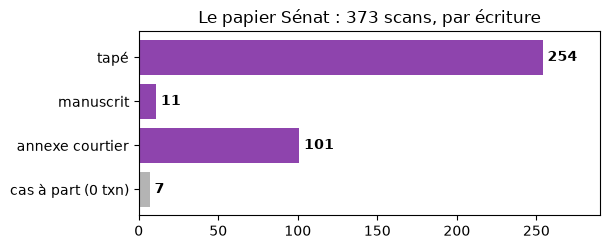

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6.2, 2.6))
cols = ["#8E44AD", "#8E44AD", "#8E44AD", "#B4B4B4"]
ys = [lab[c] for c in order][::-1]; vs = cnt.reindex(order).values[::-1]
ax.barh(ys, vs, color=cols[::-1])
for i, v in enumerate(vs): ax.text(v+3, i, str(int(v)), va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, 290); ax.set_title("Le papier Sénat : 373 scans, par écriture")
plt.tight_layout(); plt.show()

## §4 — Pourquoi Quiver corrobore 0 % du papier (la brique de la slide 2e)

Le pipeline recalcule, **chaque année**, le recoupement de notre voie OCR papier avec Quiver
(`07c_quiver_txn_reconciliation.csv`, scope `ocr`). La clé de match est le triplet
**(sénateur × ticker × sens)**. On lit `matched` (transactions présentes des deux côtés).

In [7]:
rows = []
for f in sorted(glob.glob("data/senate/tables/*/07c_quiver_txn_reconciliation.csv")):
    yr = Path(f).parent.name if False else f.split("/")[-2]
    d = pd.read_csv(f)
    o = d[d["scope"] == "ocr"].set_index("metric")["value"]
    rows.append({"année":yr, "sénateurs communs":o.get("common_senators"),
                 "trades Quiver":o.get("quiver"), "nos lignes tickerisables":o.get("ours_tickerizable"),
                 "appariés (matched)":o.get("matched"), "couverture %":o.get("coverage_pct")})
q = pd.DataFrame(rows)
display(q)
print("total appariés sur 13 ans :", int(q["appariés (matched)"].fillna(0).sum()),
      "→ Quiver corrobore 0 % du papier Sénat (mesuré, pas affirmé)")

,année,sénateurs communs,trades Quiver,nos lignes tickerisables,appariés (matched),couverture %
0,2014,7.0,450.0,19.0,0.0,0.0
1,2015,1.0,38.0,0.0,0.0,0.0
2,2016,0.0,0.0,0.0,0.0,NaN
3,2017,1.0,3.0,0.0,0.0,0.0
4,2018,0.0,0.0,0.0,0.0,NaN
5,2019,0.0,0.0,0.0,0.0,NaN
6,2020,0.0,0.0,0.0,0.0,NaN
7,2021,0.0,0.0,0.0,0.0,NaN
8,2022,0.0,0.0,0.0,0.0,NaN
9,2023,1.0,14.0,64.0,0.0,0.0


total appariés sur 13 ans : 0 → Quiver corrobore 0 % du papier Sénat (mesuré, pas affirmé)


## §5 — Ce qui part au deck, et la nuance House / Sénat (sourcée)

**Galerie « Le papier Sénat : trois écritures »** — comptes ci-dessus (§3) :
**tapé 254 · manuscrit 11 · annexe courtier 101** (= 366 docs → 3 985 transactions). Les
**7 `cas_a_part`** (docs sans transaction) ne sont pas montrés sur la slide.

**Slide 2e — « Quiver ne peut rien vérifier »** — §4 : `matched = 0` chaque année → **0 %**.
Raison, **vérifiée dans le code** (pas de mémoire) :
- `_quiver_senate_cache.csv` : colonne `Ticker` remplie à **100 %** → **Quiver n'a que du coté**.
- `RAPPORT_QUALITE.md:122` : la voie OCR Sénat est à **40,4 % d'actions** seulement (le reste
  non coté : munis, LLC…), donc **~60 % hors du périmètre** actions de Quiver.
- `common/crosscheck.py:5-6`, `senate/fusion.py:91` : *« au Sénat Quiver est aveugle au papier
  (Blumenthal, Feinstein = 0 ligne), **surtout parce que l'OCR y est du non-coté** (munis/oblig.,
  hors périmètre actions de Quiver) »*.

**Nuance House / Sénat** (à ne pas confondre) : à la **Chambre**, le papier (Khanna ≈ 29 000
lignes Quiver) **est** du coté que Quiver possède → l'OCR y est **validé en externe** (~75 %) et
le manuscrit **gaté** (12,9 %). Au **Sénat**, non → **on garde tout**, sous garde-fous internes.
Ce n'est donc **pas** « Quiver ignore le papier » : c'est que le papier Sénat est **non-coté** et
porté par des sénateurs hors couverture Quiver.